In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import pandas as pd
from scipy.interpolate import griddata


In [11]:
output

<xarray.Dataset> Size: 579MB
Dimensions:                           (year: 4, time: 209, latitude: 200,
                                       longitude: 200)
Coordinates:
  * year                              (year) int64 32B 2020 2021 2022 2023
  * time                              (time) datetime64[ns] 2kB 2020-01-01 .....
  * latitude                          (latitude) float32 800B 10.12 ... 59.88
  * longitude                         (longitude) float32 800B -59.88 ... -10.12
    depth                             int16 2B ...
Data variables: (12/38)
    chl                               (year, time, latitude, longitude) float32 134MB ...
    bbp                               (year, time, latitude, longitude) float32 134MB ...
    poc                               (year, time, latitude, longitude) float32 134MB ...
    PAR                               (year, time, latitude, longitude) float32 134MB ...
    BIOME                             (year, latitude, longitude) float64 1MB ...
    BLOOM_MAXIMUM_CHLA                (year, latitude, longitude) float64 1MB ...
    ...                                ...
    BLOOM_INITIATION_RC_BBP700        (year, latitude, longitude) float64 1MB ...
    BLOOM_TERMINATION_RC_BBP700       (year, latitude, longitude) float64 1MB ...
    BLOOM_DURATION_RC_BBP700          (year, latitude, longitude) float64 1MB ...
    BLOOM_INITIATION_RC_DATE_BBP700   (year, latitude, longitude) datetime64[ns] 1MB ...
    BLOOM_TERMINATION_RC_DATE_BBP700  (year, latitude, longitude) datetime64[ns] 1MB ...
    mhw_count                         (year, latitude, longitude) float64 1MB ...
Attributes:
    title:        Global Ocean 3D Chlorophyll-a concentration, Particulate Ba...
    project:      CMEMS - MULTIOBS Thematic Assembly Center
    project_url:  http://marine.copernicus.eu
    contact:      servicedesk.cmems@mercator-ocean.eu
    description:  CMEMS MULTIOBS 3D BGC weekly global product estimated from ...
    Conventions:  CF-1.6
    institution:  LOV/IMEV/CNRS
    domain_name:  GLO
    references:   Sauzede et al. 2016 (Journal of Geophysical Research; https...

In [5]:
output = xr.open_dataset('../../../gobgc26_example/data/soca_bloom_pheno_test.nc')
output.close()

XX, YY = np.meshgrid(output.longitude.values, output.latitude.values)

In [12]:
yr_range

array([2020, 2021, 2022, 2023])

In [6]:
# Add MHW mask
add_mask = True
yr_range = output.year.values
if add_mask:
    mhw_mask = xr.open_dataset('mhw_mask.nc')
    mhw_mask.close()
    
    XX_SOCA, YY_SOCA = np.meshgrid(output.longitude.values, output.latitude.values)
    
    all_mhw = np.zeros((yr_range.shape[0], XX_SOCA.shape[0], XX_SOCA.shape[1]))*np.nan
    
    XX_MHW, YY_MHW = np.meshgrid(mhw_mask.lon.values-360, mhw_mask.lat.values)
    points = (XX_MHW.flatten(), YY_MHW.flatten())
    for yi, year in enumerate(yr_range):
    
        # Down sample to match SOCA grid
        mwh_flags = griddata(points, 
                             mhw_mask.mhw_counts.values[np.where(mhw_mask.year.values == year)[0], :,:].flatten(), 
                               (XX_SOCA, YY_SOCA), method='nearest').reshape(XX_SOCA.shape)
        all_mhw[yi,:] = mwh_flags.reshape(XX_SOCA.shape)
    
    output['mhw_count'] = (['year','latitude','longitude'], all_mhw)


In [7]:
# Load MHW data
mhw_dates = pd.read_csv('../../MHW_list.csv')
mhw = 'NA 2023'
lon0, lon1, lat0, lat1 = mhw_dates.loc[(mhw_dates.loc[:,'name']==mhw), ['lon0','lon1','lat0','lat1']].values[0,:]

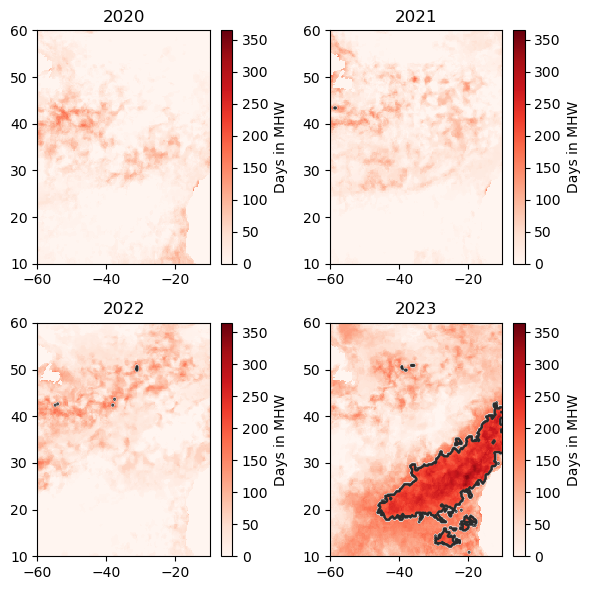

In [69]:
fig = plt.figure(figsize = (6,6))
rr = 2; cc = 2

thresh  = 0.5

for yi, yr in enumerate(yr_range):

    ax = fig.add_subplot(rr, cc, yi+1)

    Z = output.mhw_count.values[yi, :, :]
    Z_thresh = np.where(output.mhw_count.values[yi, :, :]/365<thresh, 0, 1)
    # Z = output.mhw_count.values[yi, :, :]/365
    cm=ax.pcolormesh(XX, YY, Z, cmap = 'Reds', vmin = 0, vmax = 365);
    ax.contour(XX, YY, Z_thresh, cmap = 'Greys');

    ax.set_title(yr)
    fig.colorbar(cm, ax=ax, label='Days in MHW')
fig.tight_layout()

/var/folders/lj/ln2kqf0x2k795vs_453ytwp00000gn/T/ipykernel_4107/3430312821.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


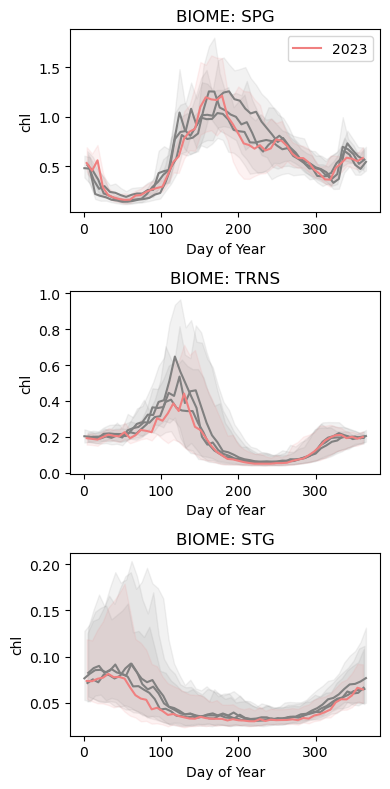

In [50]:
biome_list = np.array([9, 10, 11])
biome_labels = ['SPG','TRNS','STG']
fig = plt.figure(figsize = (4, 8))
rr = 3; cc = 1

for bi, biome in enumerate(biome_list):

    if bi == 0:
        ax1 = fig.add_subplot(rr, cc, bi+1)
        # ax2 = fig.add_subplot(rr, cc, bi+1+cc)
        # ax3 = fig.add_subplot(rr, cc, bi+1+2*cc)
    else:
        # ax1 = fig.add_subplot(rr, cc, bi+1, sharey = ax1)
        ax1 = fig.add_subplot(rr, cc, bi+1)
        # ax2 = fig.add_subplot(rr, cc, bi+1+cc, sharey = ax2)
        # ax3 = fig.add_subplot(rr, cc, bi+1+2*cc, sharey = ax3)
    
    for yi, year in enumerate(yr_range):
    
        subset = output.sel(year = year)
        
        binds = np.where(subset.BIOME.values == biome)
    
        x = np.array([pd.Timestamp(ti).dayofyear for ti in subset.time.values])
    
        param_list = ['chl'] #, 'poc', 'log10(chl/bbp)']
        ax_list = [ax1] #, ax2, ax3]

        if year == 2023:
            color = 'lightcoral'
            label = '2023'
        else:
            color = 'grey'
            label = ''
            
        for pi, param in enumerate(param_list):
            ax = ax_list[pi]
    
            if param == 'log10(chl/bbp)':
                plot_values = np.log10(subset['chl'].values[:,binds[0], binds[1]]/subset['bbp'].values[:,binds[0], binds[1]])
                # plot_values = np.log10(subset['bbp'].values[:,binds[0], binds[1]]/subset['chl'].values[:,binds[0], binds[1]])
            else:
                plot_values = subset[param].values[:,binds[0], binds[1]]
            
            ax.fill_between(x, np.nanquantile(plot_values,0.25,axis = 1),
                             np.nanquantile(plot_values,0.75,axis = 1),alpha = 0.1,
                           color = color)
            ax.plot(x, np.nanmedian(plot_values,axis = 1),
                    label = label, color = color)


            ax.set_ylabel(param)
            ts = 'BIOME: '+biome_labels[bi]
            ax.set_title(ts)
            ax.set_xlabel('Day of Year')

        if bi == 0:
            ax.legend()

fig.tight_layout()

/var/folders/lj/ln2kqf0x2k795vs_453ytwp00000gn/T/ipykernel_4107/2029857001.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


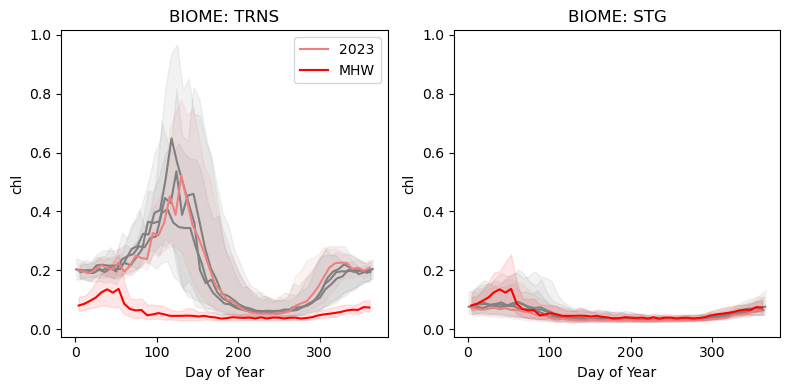

In [58]:
biome_list = np.array([10, 11])
biome_labels = ['TRNS','STG']
fig = plt.figure(figsize = (8, 4))
rr = 1; cc = 2

for bi, biome in enumerate(biome_list):

    if bi == 0:
        ax1 = fig.add_subplot(rr, cc, bi+1)
    else:
        ax1 = fig.add_subplot(rr, cc, bi+1, sharey = ax)
    
    for yi, year in enumerate(yr_range):
    
        subset = output.sel(year = year)
        thresh  = 0.5
        Z = np.where(subset.mhw_count.values[:, :]/365<thresh, 0, 1)

        binds = np.where((subset.BIOME.values == biome) & (Z  == 0))
        minds = np.where( (Z  == 1))
        x = np.array([pd.Timestamp(ti).dayofyear for ti in subset.time.values])
    
        param_list = ['chl'] #, 'poc', 'log10(chl/bbp)']
        ax_list = [ax1] #, ax2, ax3]

        if year == 2023:
            color = 'lightcoral'
            label = '2023'
        else:
            color = 'grey'
            label = ''
            
        for pi, param in enumerate(param_list):
            ax = ax_list[pi]
    

            plot_values = subset[param].values[:,binds[0], binds[1]]
            
            ax.fill_between(x, np.nanquantile(plot_values,0.25,axis = 1),
                             np.nanquantile(plot_values,0.75,axis = 1),alpha = 0.1,
                           color = color)
            ax.plot(x, np.nanmedian(plot_values,axis = 1),
                    label = label, color = color)

            if year == 2023:
                plot_values = subset[param].values[:,minds[0], minds[1]]
                color = 'red'
                label = 'MHW'
                ax.fill_between(x, np.nanquantile(plot_values,0.25,axis = 1),
                             np.nanquantile(plot_values,0.75,axis = 1),alpha = 0.1,
                           color = color)
                ax.plot(x, np.nanmedian(plot_values,axis = 1),
                        label = label, color = color)


            ax.set_ylabel(param)
            ts = 'BIOME: '+biome_labels[bi]
            ax.set_title(ts)
            ax.set_xlabel('Day of Year')

        if bi == 0:
            ax.legend()


fig.tight_layout()

/var/folders/lj/ln2kqf0x2k795vs_453ytwp00000gn/T/ipykernel_1670/1135942695.py:42: RuntimeWarning: All-NaN slice encountered
  ax.plot(x, np.nanmedian(plot_values,axis = 1), color = color, label ='MHW Flag: '+str(mhw_flag))


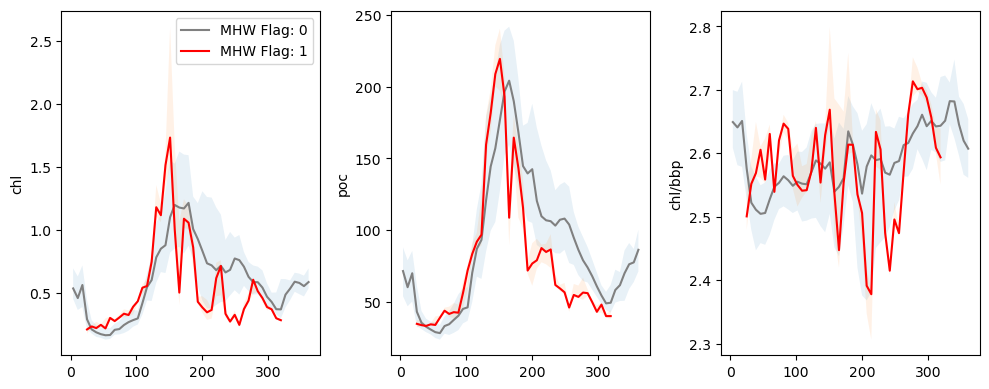

In [119]:
biome = 9
year = 2023

fig = plt.figure(figsize = (10, 4))
rr = 1; cc = 3

ax1 = fig.add_subplot(rr, cc, 1)
subset = output.sel(year = year)

thresh  = 0.5
Z = np.where(subset.mhw_count.values[:, :]/365<thresh, 0, 1)

x = np.array([pd.Timestamp(ti).dayofyear for ti in subset.time.values])

param_list = ['chl', 'poc', 'chl/bbp']
ax_list = [ax1, ax2, ax3]


for mhw_flag in [0, 1]:
    
    if mhw_flag == 1:
        color = 'red'
    else:
        color = 'grey'

    binds = np.where((subset.BIOME.values[:,:] == biome) & (Z == mhw_flag))
    
    for pi, param in enumerate(param_list):
        ax = ax_list[pi]
    
        if param == 'chl/bbp':
            plot_values = np.log10(subset['chl'].values[:,binds[0], binds[1]]/subset['bbp'].values[:,binds[0], binds[1]])
            # plot_values = np.log10(subset['bbp'].values[:,binds[0], binds[1]]/subset['chl'].values[:,binds[0], binds[1]])
        else:
            plot_values = subset[param].values[:,binds[0], binds[1]]
        
        ax.fill_between(x, np.nanquantile(plot_values,0.25,axis = 1),
                         np.nanquantile(plot_values,0.75,axis = 1),alpha = 0.1)
        ax.plot(x, np.nanmedian(plot_values,axis = 1), color = color, label ='MHW Flag: '+str(mhw_flag))

        ax.set_ylabel(param)
        
ax1.legend()
fig.tight_layout()

/var/folders/lj/ln2kqf0x2k795vs_453ytwp00000gn/T/ipykernel_4107/3218742670.py:4: RuntimeWarning: Mean of empty slice
  Z = np.nanmean(output.chl.values[yi,:,:,:],axis = 0)


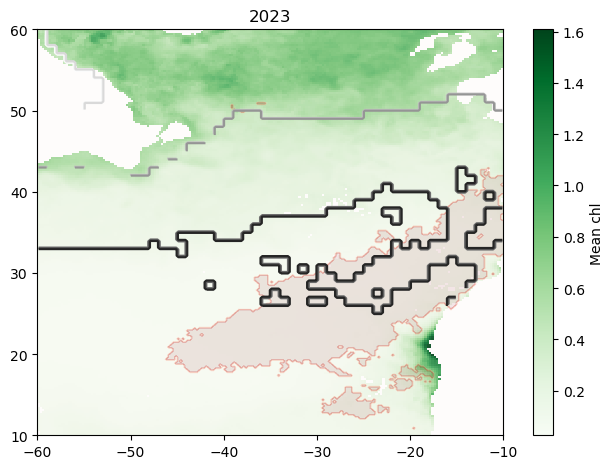

In [39]:
yr = 2023
yi = np.where(yr_range == yr)[0][0]

Z = np.nanmean(output.chl.values[yi,:,:,:],axis = 0)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
cm = ax.pcolormesh(XX, YY, Z, cmap = 'Greens')

ax.contour(XX, YY, output['BIOME'].values[yi,:,:], cmap = 'Greys')

thresh  = 0.5
Z = np.where(output.mhw_count.values[yi, :, :]/365<thresh, 0, 1)
ax.contourf(XX, YY, Z, cmap = 'Reds',alpha =0.1);

ax.set_title(year)
fig.colorbar(cm, ax = ax, label = 'Mean chl')

# ax = fig.add_subplot(rr, cc, yi+1)
# ax.pcolormesh(XX, YY, output['BIOME'].values[yi,:,:])
fig.tight_layout()

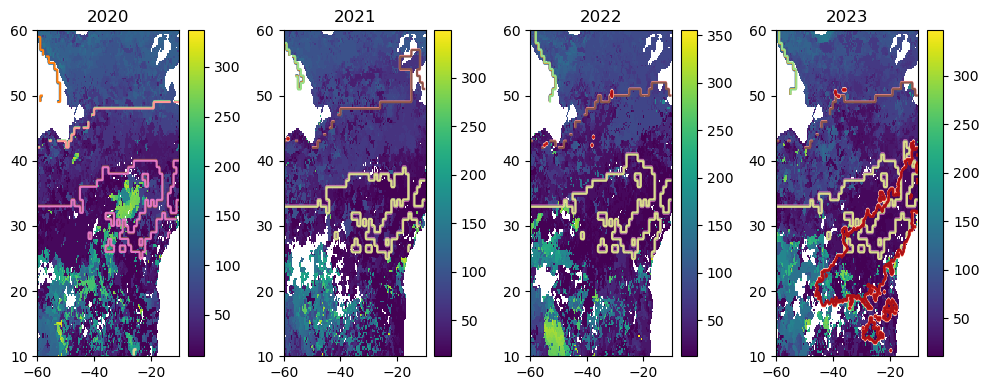

In [79]:
fig = plt.figure(figsize = (10,4))

rr = 1; cc = 4

optic_param = 'CHLA'
bloom_param = 'BLOOM_MAXIMUM_'+optic_param
bloom_param = 'BLOOM_INITIATION_TS_DATE_'+optic_param
for yi, year in enumerate(yr_range):

    if 'DATE' in bloom_param:
        Z0 = output[bloom_param].values[yi,:,:]
        Z = np.zeros(Z0.shape)*np.nan
        
        for ri in np.arange(Z.shape[0]):
            for ci in np.arange(Z.shape[1]):
                Z[ri,ci] = pd.Timestamp(Z0[ri,ci]).dayofyear
    else:
        Z = output[bloom_param].values[yi,:,:]
        
    ax = fig.add_subplot(rr,cc,yi+1)
    cm = ax.pcolormesh(XX, YY, Z)

    ax.contour(XX, YY, output['BIOME'].values[yi,:,:], cmap = 'tab20')

    thresh  = 0.5
    Z = np.where(output.mhw_count.values[yi, :, :]/365<thresh, 0, 1)
    ax.contour(XX, YY, Z, cmap = 'Reds');

    ax.set_title(year)
    fig.colorbar(cm, ax = ax)

# ax = fig.add_subplot(rr, cc, yi+1)
# ax.pcolormesh(XX, YY, output['BIOME'].values[yi,:,:])
fig.tight_layout()

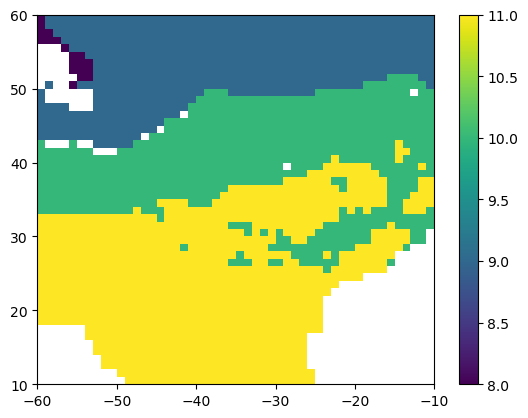

In [108]:

plt.pcolormesh(XX, YY, output['BIOME'].values[yi,:,:])
plt.colorbar()